# Financial Asset Recommendation System

## Part 2 — Exploratory data analysis

In [12]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from src.config import RAW_DATA_DIR
assets=pd.read_csv(RAW_DATA_DIR/'assets.csv')
users=pd.read_csv(RAW_DATA_DIR/'users.csv')
interactions=pd.read_csv(RAW_DATA_DIR/'interactions.csv',parse_dates=['timestamp'])
len(assets),len(users),len(interactions)

(60, 600, 7731)

## 1. Data dictionaries

`assets.csv` contains fictional financial instruments and finance-shaped numerical features. `users.csv` contains investor characteristics. `interactions.csv` contains implicit-feedback events where view=1, watchlist=2 and buy=4.

In [14]:
display(assets.head())
display(users.head())
display(interactions.head())

,ticker,company_name,sector,annual_return,volatility,beta,pe_ratio,dividend_yield,market_cap_billion
0,FAS001,Synthetic Capital 001,Technology,0.2314,0.4327,1.435,14.52,0.0156,255.85
1,FAS002,Synthetic Capital 002,Utilities,0.1053,0.2034,0.822,23.16,0.0207,93.67
2,FAS003,Synthetic Capital 003,Consumer,0.0825,0.1939,0.706,19.23,0.0339,20.14
3,FAS004,Synthetic Capital 004,Energy,0.0936,0.1668,0.827,51.52,0.0323,14.03
4,FAS005,Synthetic Capital 005,Energy,0.0422,0.2954,1.162,40.77,0.0196,46.73


,user_id,age,experience_years,risk_profile,preferred_sector,investment_horizon
0,U00001,36,5,balanced,Consumer,long
1,U00002,67,7,conservative,Consumer,long
2,U00003,27,7,conservative,Technology,medium
3,U00004,67,3,aggressive,Utilities,short
4,U00005,45,4,balanced,Technology,long


,user_id,ticker,event_type,interaction_weight,timestamp
0,U00463,FAS043,watchlist,2.0,2022-01-01
1,U00262,FAS049,watchlist,2.0,2022-01-01
2,U00159,FAS019,buy,4.0,2022-01-01
3,U00012,FAS012,view,1.0,2022-01-01
4,U00493,FAS026,watchlist,2.0,2022-01-01


## 2. Data quality checks

In [15]:
print('Assets duplicates:',assets.ticker.duplicated().sum())
print('Users duplicates:',users.user_id.duplicated().sum())
print('Missing values:')
display(pd.concat({'assets':assets.isna().sum(),'users':users.isna().sum(),'interactions':interactions.isna().sum()},axis=1).fillna(0).astype(int))

Assets duplicates: 0
Users duplicates: 0
Missing values:


,assets,users,interactions
ticker,0,0,0
company_name,0,0,0
sector,0,0,0
annual_return,0,0,0
volatility,0,0,0
beta,0,0,0
pe_ratio,0,0,0
dividend_yield,0,0,0
market_cap_billion,0,0,0
user_id,0,0,0


## 3. Asset catalog

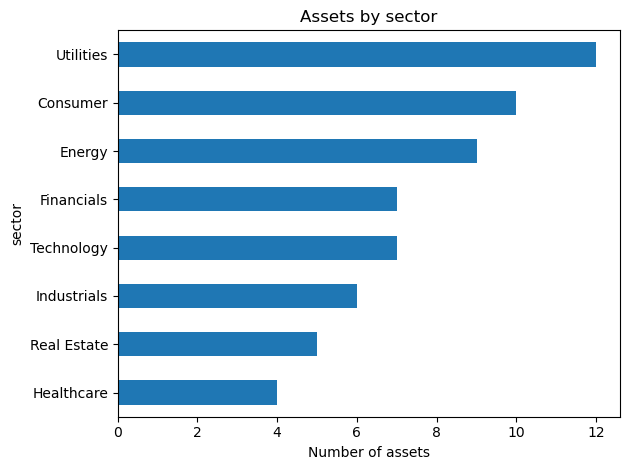

In [16]:
assets['sector'].value_counts().sort_values().plot.barh(title='Assets by sector')
plt.xlabel('Number of assets'); plt.tight_layout(); plt.show()

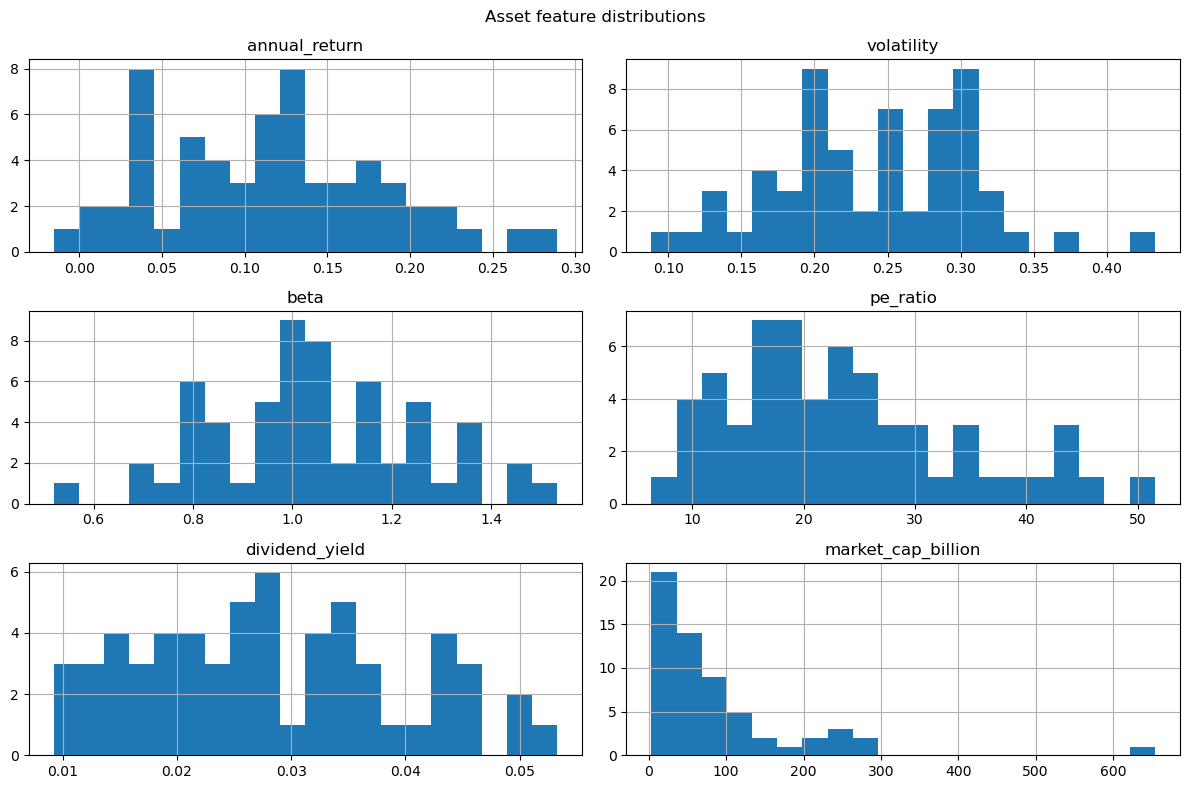

In [17]:
assets[['annual_return','volatility','beta','pe_ratio','dividend_yield','market_cap_billion']].hist(figsize=(12,8),bins=20)
plt.suptitle('Asset feature distributions'); plt.tight_layout(); plt.show()

## 4. Investor profiles

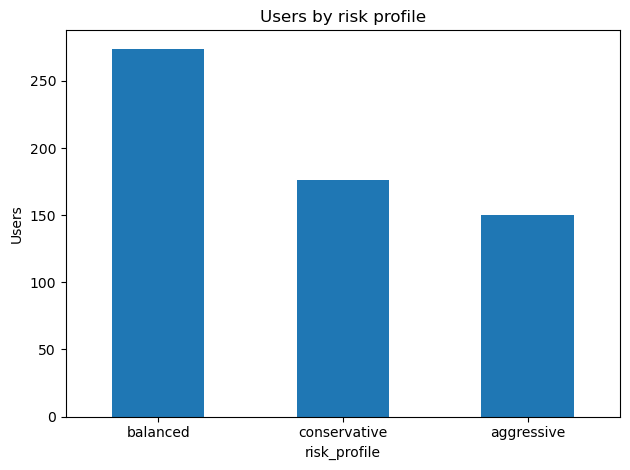

In [18]:
users['risk_profile'].value_counts().plot.bar(title='Users by risk profile')
plt.ylabel('Users'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

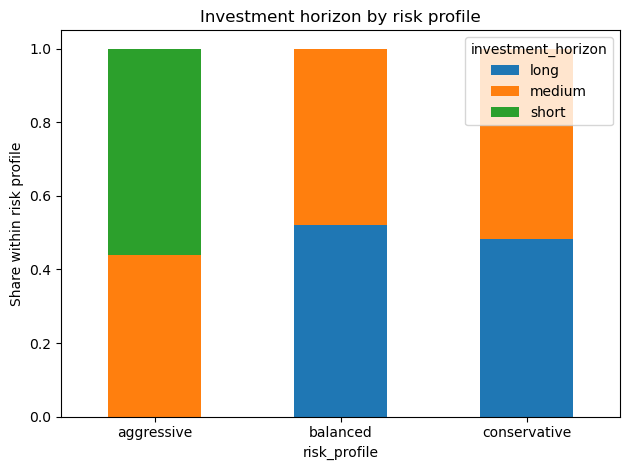

In [19]:
pd.crosstab(users.risk_profile,users.investment_horizon,normalize='index').plot.bar(stacked=True,title='Investment horizon by risk profile')
plt.ylabel('Share within risk profile'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 5. Interaction behavior

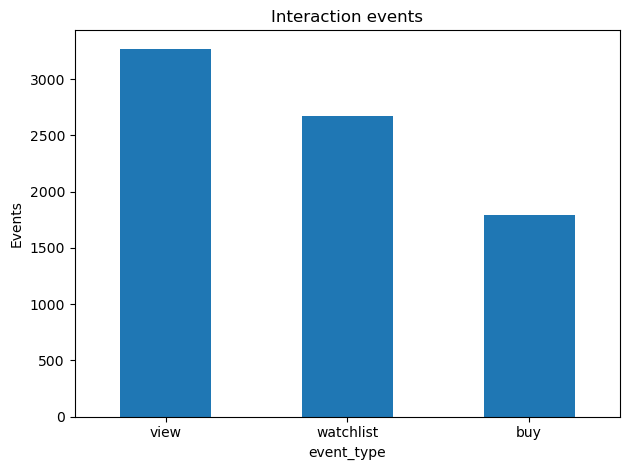

In [20]:
interactions.event_type.value_counts().plot.bar(title='Interaction events')
plt.ylabel('Events'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

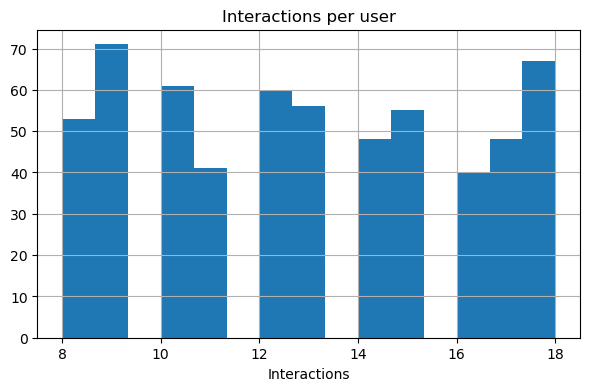

In [21]:
per_user=interactions.groupby('user_id').size()
per_asset=interactions.groupby('ticker').size()
fig,ax=plt.subplots(figsize=(7,4)); per_user.hist(ax=ax,bins=15); ax.set_title('Interactions per user'); ax.set_xlabel('Interactions'); plt.show()

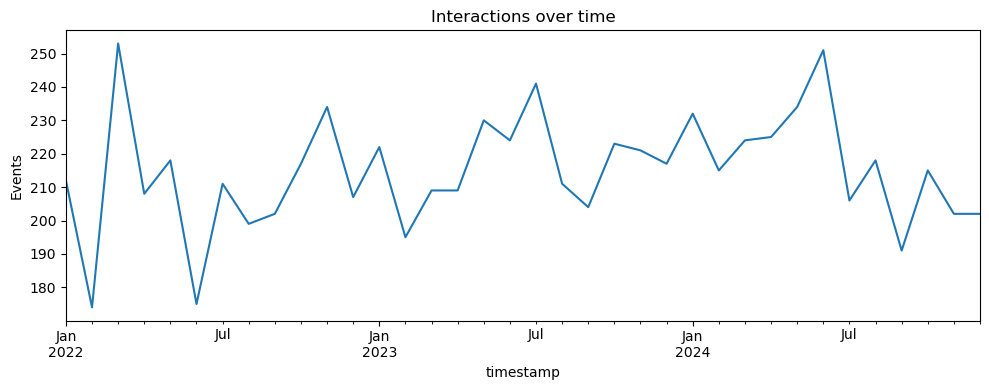

In [22]:
monthly=interactions.set_index('timestamp').resample('MS').size()
monthly.plot(title='Interactions over time',figsize=(10,4)); plt.ylabel('Events'); plt.tight_layout(); plt.show()

## 6. EDA conclusions

The dataset has complete identifiers and no missing values. It contains multiple sectors, risk profiles and interaction types. Interactions span three years, which supports chronological evaluation. Because the data is synthetic, observed relationships should be interpreted as validation of the experimental pipeline rather than evidence about actual investors.